# Análise dos resultados do modelo estocástico (TRAIL/WALK, MTZ/EXP)

Resultados em `stochastic-results-model/` no padrão:
`experiment-{alpha}-{model}-{model_type}-{use_preprocessing}`

Objetivos:
1. Identificar melhor variação (model × model_type × preprocessing)
2. Focar na **TRAIL-EXP-1** e analisar por alpha
3. Contar soluções ótimas por abordagem
4. Cruzar com dados de input (grafo + cenários) para entender o impacto do alpha
5. Exportar cada configuração para LaTeX

In [1]:
import os, sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.figsize"] = (10, 6)
matplotlib.rcParams["axes.grid"] = True
matplotlib.rcParams["grid.alpha"] = 0.3

import analysis_utils
import importlib
importlib.reload(analysis_utils)

from analysis_utils import (
    parse_experiment_folder_model,
    parse_experiment_name_model,
    export_model_config_to_latex,
    instance_sort_key,
    load_all_instance_data,
)

BASE_MODEL = Path("stochastic-results-model")
INSTANCE_FOLDERS = ["instances/simulated-alto-santo", "instances/simulated-limoeiro"]
if not BASE_MODEL.exists():
    raise FileNotFoundError(f"Pasta {BASE_MODEL} não encontrada.")

In [2]:
# Carregar todos os resultados
raw = parse_experiment_folder_model(BASE_MODEL)
records = [r for _, r in raw]
df_all = pd.DataFrame(records)

params = [parse_experiment_name_model(r["experiment"]) for _, r in raw]
if params:
    for k in params[0].keys():
        df_all[k] = [p.get(k) for p in params]

df_all["gap_pct"] = pd.to_numeric(df_all["gap_pct"], errors="coerce")
df_all["config"] = df_all["model"] + "-" + df_all["model_type"] + "-" + df_all["use_preprocessing"].astype(str)

# Carregar dados de input (grafo + cenários)
inst_data = load_all_instance_data(INSTANCE_FOLDERS)

print(f"Total de resultados: {len(df_all)}")
print(f"Experimentos: {df_all['experiment'].nunique()}")
print(f"Configurações únicas (model-type-prep): {df_all['config'].nunique()}")
print(f"Instâncias carregadas (input): {len(inst_data)}")
df_all.head(3)

Total de resultados: 2872
Experimentos: 80
Configurações únicas (model-type-prep): 8
Instâncias carregadas (input): 36


,instance_name,attended_s0,attended_per_scenario,attended_avg,N,M,B,S,Alpha,LB,...,Lazy_cuts,Frac_cuts,Runtime,gap_pct,experiment,alpha,model,model_type,use_preprocessing,config
0,alto-santo-500-5,2,"[2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...",0.431373,117,336,52,50,0.1,5.85,...,820418,0,784.731,93.012422,experiment-0.1-TRAIL-EXP-0,0.1,TRAIL,EXP,0,TRAIL-EXP-0
1,alto-santo-500-6,0,"[0, 1, 2, 1, 2, 6, 0, 3, 0, 0, 0, 3, 1, 0, 12,...",2.039216,117,336,52,50,0.1,4.16,...,823760,0,729.260,97.808450,experiment-0.1-TRAIL-EXP-0,0.1,TRAIL,EXP,0,TRAIL-EXP-0
2,alto-santo-1000-5,2,"[2, 0, 0, 0, 3, 0, 0, 0, 1, 0, 1, 0, 4, 0, 1, ...",0.627451,179,524,84,50,0.1,6.29,...,639950,0,340.827,94.175926,experiment-0.1-TRAIL-EXP-0,0.1,TRAIL,EXP,0,TRAIL-EXP-0


## 1. Observação: o modelo/tipo não afeta a solução, apenas o tempo

Para um mesmo alpha e preprocessing, TRAIL-EXP, TRAIL-MTZ, WALK-EXP e WALK-MTZ produzem **a mesma solução** (mesmo LB, UB, gap, blocos atendidos). A diferença é apenas no tempo de resolução. Isso faz sentido pois o modelo estocástico resolve o mesmo problema — a formulação (TRAIL vs WALK, MTZ vs EXP) afeta apenas a estratégia de resolução do Gurobi.

In [3]:
# Verificar: para mesmo alpha + prep + instância, as 4 configs dão mesmo LB?
check = df_all.groupby(["alpha", "use_preprocessing", "instance_name"]).agg(
    LB_nunique=("LB", "nunique"),
    UB_nunique=("UB", "nunique"),
    att_s0_nunique=("attended_s0", "nunique"),
).reset_index()
print("Casos em que LB difere entre 4 configs (mesmo alpha+prep+inst):", (check["LB_nunique"] > 1).sum())
print("Casos em que UB difere:", (check["UB_nunique"] > 1).sum())
print("Casos em que att_s0 difere:", (check["att_s0_nunique"] > 1).sum())
print("\n=> As 4 configurações são equivalentes em qualidade de solução.")
print("   Vamos focar em TRAIL-EXP-1 como representante.")

Casos em que LB difere entre 4 configs (mesmo alpha+prep+inst): 1
Casos em que UB difere: 3
Casos em que att_s0 difere: 0

=> As 4 configurações são equivalentes em qualidade de solução.
   Vamos focar em TRAIL-EXP-1 como representante.


In [25]:
df_all.query("instance_name == 'limoeiro-2000-1' and alpha == 0.1").sort_values("Runtime")

,instance_name,attended_s0,attended_per_scenario,attended_avg,N,M,B,S,Alpha,LB,...,Lazy_cuts,Frac_cuts,Runtime,gap_pct,experiment,alpha,model,model_type,use_preprocessing,config
185,limoeiro-2000-1,4,"[4, 1, 1, 1, 1, 3, 2, 2, 3, 2, 1, 2, 1, 2, 2, ...",1.862745,750,2351,531,50,0.1,9.456,...,473864,0,278.264,95.672846,experiment-0.1-WALK-EXP-1,0.1,WALK,EXP,1,WALK-EXP-1
43,limoeiro-2000-1,4,"[4, 1, 1, 1, 1, 3, 2, 2, 3, 2, 1, 2, 1, 2, 2, ...",1.862745,750,2351,531,50,0.1,9.456,...,473864,0,279.616,95.672846,experiment-0.1-TRAIL-EXP-1,0.1,TRAIL,EXP,1,TRAIL-EXP-1
114,limoeiro-2000-1,4,"[4, 1, 1, 1, 1, 3, 2, 2, 3, 2, 1, 2, 1, 2, 2, ...",1.862745,750,2351,531,50,0.1,9.456,...,473864,0,283.924,95.672846,experiment-0.1-TRAIL-MTZ-1,0.1,TRAIL,MTZ,1,TRAIL-MTZ-1
256,limoeiro-2000-1,4,"[4, 1, 1, 1, 1, 3, 2, 2, 3, 2, 1, 2, 1, 2, 2, ...",1.862745,750,2351,531,50,0.1,9.456,...,473864,0,285.109,95.672846,experiment-0.1-WALK-MTZ-1,0.1,WALK,MTZ,1,WALK-MTZ-1
78,limoeiro-2000-1,4,"[4, 1, 1, 1, 2, 3, 2, 2, 3, 2, 2, 1, 2, 2, 2, ...",2.196078,1008,3112,549,50,0.1,12.266,...,631964,0,448.331,94.420665,experiment-0.1-TRAIL-MTZ-0,0.1,TRAIL,MTZ,0,TRAIL-MTZ-0
149,limoeiro-2000-1,4,"[4, 1, 1, 1, 2, 3, 2, 2, 3, 2, 2, 1, 2, 2, 2, ...",2.196078,1008,3112,549,50,0.1,12.266,...,631964,0,449.198,94.420665,experiment-0.1-WALK-EXP-0,0.1,WALK,EXP,0,WALK-EXP-0
7,limoeiro-2000-1,4,"[4, 1, 1, 1, 2, 3, 2, 2, 3, 2, 2, 1, 2, 2, 2, ...",2.196078,1008,3112,549,50,0.1,12.266,...,631964,0,450.528,94.420665,experiment-0.1-TRAIL-EXP-0,0.1,TRAIL,EXP,0,TRAIL-EXP-0
220,limoeiro-2000-1,4,"[4, 1, 1, 1, 2, 3, 2, 2, 3, 2, 2, 1, 2, 2, 2, ...",2.196078,1008,3112,549,50,0.1,12.266,...,631964,0,452.178,94.420665,experiment-0.1-WALK-MTZ-0,0.1,WALK,MTZ,0,WALK-MTZ-0


In [4]:
# Tempo médio por config (para ver qual é mais rápida)
time_by_config = df_all.groupby("config")["Runtime"].mean().sort_values()
print("Runtime médio por configuração:")
print(time_by_config.to_string())

Runtime médio por configuração:
config
WALK-EXP-0     392.544263
TRAIL-MTZ-0    396.449804
TRAIL-EXP-0    398.177845
WALK-MTZ-0     399.487366
TRAIL-EXP-1    460.076600
WALK-MTZ-1     460.601297
WALK-EXP-1     460.791239
TRAIL-MTZ-1    461.449164


## 2. Foco: TRAIL-EXP-1 — análise por alpha

Filtramos apenas a configuração TRAIL-EXP com preprocessing=1 e analisamos como o alpha afeta a solução.

In [5]:
df_best = df_all[df_all["config"] == "TRAIL-EXP-1"].copy()
df_best = df_best.sort_values("instance_name", key=lambda c: c.map(instance_sort_key))
print(f"TRAIL-EXP-1: {len(df_best)} resultados, {df_best['instance_name'].nunique()} instâncias, {df_best['alpha'].nunique()} valores de alpha")

by_alpha = df_best.groupby("alpha").agg(
    LB_medio=("LB", "mean"),
    UB_medio=("UB", "mean"),
    gap_medio=("gap_pct", "mean"),
    gap_std=("gap_pct", "std"),
    attended_s0_medio=("attended_s0", "mean"),
    attended_s0_std=("attended_s0", "std"),
    runtime_medio=("Runtime", "mean"),
    n_optimal=("gap_pct", lambda x: (x == 0).sum()),
    n_results=("gap_pct", "count"),
).reset_index()
by_alpha

TRAIL-EXP-1: 360 resultados, 36 instâncias, 10 valores de alpha


,alpha,LB_medio,UB_medio,gap_medio,gap_std,attended_s0_medio,attended_s0_std,runtime_medio,n_optimal,n_results
0,0.1,15.173056,157.300053,89.216815,8.849386,3.277778,2.625274,416.176942,0,36
1,0.2,16.387889,157.374444,88.761542,8.515587,3.722222,3.291644,343.908261,0,36
2,0.3,17.754000,157.292769,87.359294,8.869630,3.250000,2.453860,423.758031,0,36
3,0.4,17.328667,157.425067,87.301375,9.519196,3.638889,3.015700,388.168000,0,36
4,0.5,18.226389,157.641467,86.715329,9.272984,4.916667,5.022094,376.556772,0,36
5,0.6,18.171556,157.760700,86.764153,12.799883,4.972222,6.725160,414.541981,0,36
6,0.7,17.994222,157.794200,86.884028,9.831375,4.611111,6.508358,398.263119,0,36
7,0.8,19.194152,158.074292,85.386402,9.739666,3.833333,3.166792,467.529717,0,36
8,0.9,17.371528,158.267019,85.960132,10.857721,4.833333,7.287955,497.753808,0,36
9,1.0,24.841667,158.418444,78.272108,27.077221,9.055556,12.453214,874.109372,0,36


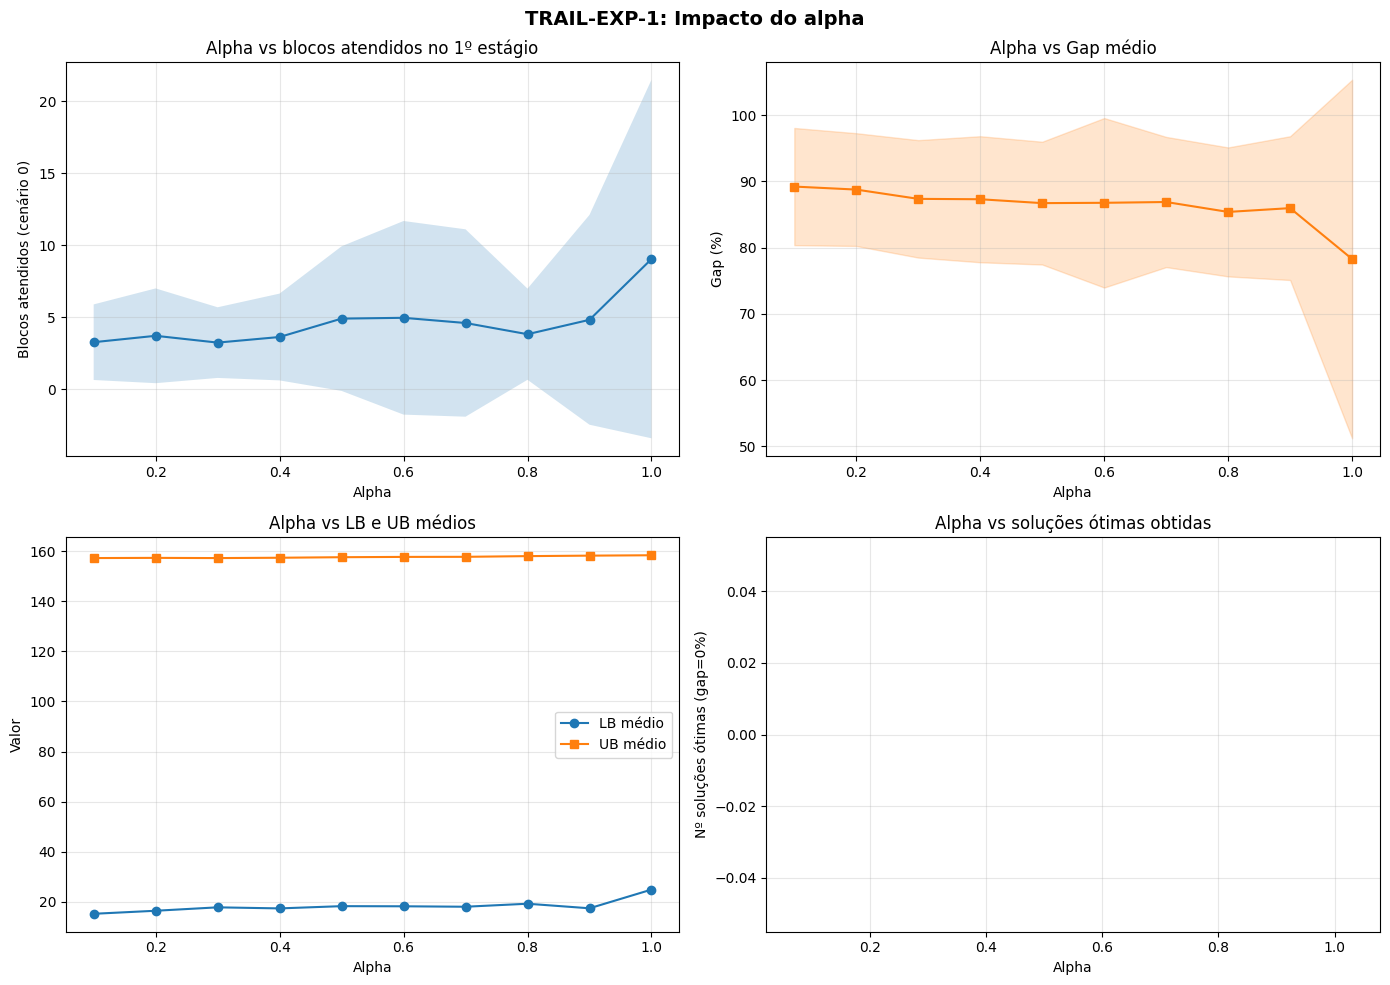

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.plot(by_alpha["alpha"], by_alpha["attended_s0_medio"], "o-", color="C0")
ax.fill_between(by_alpha["alpha"],
    by_alpha["attended_s0_medio"] - by_alpha["attended_s0_std"].fillna(0),
    by_alpha["attended_s0_medio"] + by_alpha["attended_s0_std"].fillna(0), alpha=0.2)
ax.set_xlabel("Alpha")
ax.set_ylabel("Blocos atendidos (cenário 0)")
ax.set_title("Alpha vs blocos atendidos no 1º estágio")

ax = axes[0, 1]
ax.plot(by_alpha["alpha"], by_alpha["gap_medio"], "s-", color="C1")
ax.fill_between(by_alpha["alpha"],
    by_alpha["gap_medio"] - by_alpha["gap_std"].fillna(0),
    by_alpha["gap_medio"] + by_alpha["gap_std"].fillna(0), alpha=0.2, color="C1")
ax.set_xlabel("Alpha")
ax.set_ylabel("Gap (%)")
ax.set_title("Alpha vs Gap médio")

ax = axes[1, 0]
ax.plot(by_alpha["alpha"], by_alpha["LB_medio"], "o-", label="LB médio")
ax.plot(by_alpha["alpha"], by_alpha["UB_medio"], "s-", label="UB médio")
ax.set_xlabel("Alpha")
ax.set_ylabel("Valor")
ax.set_title("Alpha vs LB e UB médios")
ax.legend()

ax = axes[1, 1]
ax.bar(by_alpha["alpha"], by_alpha["n_optimal"], width=0.06, color="C2")
ax.set_xlabel("Alpha")
ax.set_ylabel("Nº soluções ótimas (gap=0%)")
ax.set_title("Alpha vs soluções ótimas obtidas")

plt.suptitle("TRAIL-EXP-1: Impacto do alpha", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Soluções ótimas por abordagem (preprocessing=0 vs 1)

Como as 4 formulações (TRAIL/WALK × MTZ/EXP) dão a mesma solução, a distinção relevante é **preprocessing** (0 vs 1). Vamos contar quantas soluções ótimas (gap=0%) cada uma obteve, por alpha.

In [7]:
# Usar apenas 1 config representante por prep (TRAIL-EXP)
df_rep = df_all[(df_all["model"] == "TRAIL") & (df_all["model_type"] == "EXP")].copy()
opt_by_prep_alpha = df_rep.groupby(["use_preprocessing", "alpha"]).apply(
    lambda g: pd.Series({
        "n_optimal": (g["gap_pct"] == 0).sum(),
        "n_total": len(g),
        "gap_medio": g["gap_pct"].mean(),
        "attended_s0_medio": g["attended_s0"].mean(),
    })
).reset_index()

for prep in [0, 1]:
    sub = opt_by_prep_alpha[opt_by_prep_alpha["use_preprocessing"] == prep]
    total_opt = sub["n_optimal"].sum()
    print(f"\nPreprocessing={prep}: {int(total_opt)} soluções ótimas no total")
    print(sub[["alpha", "n_optimal", "n_total", "gap_medio", "attended_s0_medio"]].to_string(index=False))


Preprocessing=0: 0 soluções ótimas no total
 alpha  n_optimal  n_total  gap_medio  attended_s0_medio
   0.1        0.0     35.0  89.488354           6.057143
   0.2        0.0     36.0  89.875666           3.722222
   0.3        0.0     36.0  91.150422           4.611111
   0.4        0.0     36.0  89.120242           5.611111
   0.5        0.0     35.0  89.504566           4.285714
   0.6        0.0     36.0  88.535237           5.111111
   0.7        0.0     36.0  89.051065           4.694444
   0.8        0.0     36.0  88.951229           4.194444
   0.9        0.0     36.0  88.379797           5.222222
   1.0        0.0     36.0  86.086292           6.055556

Preprocessing=1: 0 soluções ótimas no total
 alpha  n_optimal  n_total  gap_medio  attended_s0_medio
   0.1        0.0     36.0  89.216815           3.277778
   0.2        0.0     36.0  88.761542           3.722222
   0.3        0.0     36.0  87.359294           3.250000
   0.4        0.0     36.0  87.301375           3.63888

/tmp/ipykernel_7012/2334131993.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  opt_by_prep_alpha = df_rep.groupby(["use_preprocessing", "alpha"]).apply(


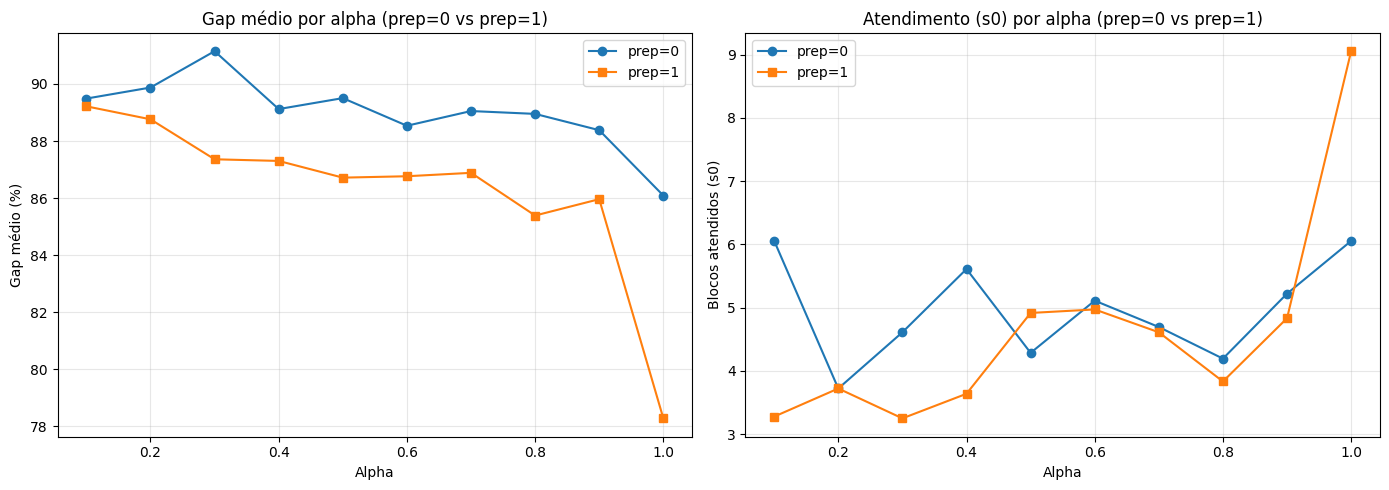

In [8]:
# Plot comparativo prep=0 vs prep=1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for prep, color, marker in [(0, "C0", "o"), (1, "C1", "s")]:
    sub = opt_by_prep_alpha[opt_by_prep_alpha["use_preprocessing"] == prep]
    axes[0].plot(sub["alpha"], sub["gap_medio"], f"{marker}-", color=color, label=f"prep={prep}")
    axes[1].plot(sub["alpha"], sub["attended_s0_medio"], f"{marker}-", color=color, label=f"prep={prep}")

axes[0].set_xlabel("Alpha"); axes[0].set_ylabel("Gap médio (%)")
axes[0].set_title("Gap médio por alpha (prep=0 vs prep=1)")
axes[0].legend()
axes[1].set_xlabel("Alpha"); axes[1].set_ylabel("Blocos atendidos (s0)")
axes[1].set_title("Atendimento (s0) por alpha (prep=0 vs prep=1)")
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Por que o gap não segue um padrão monotônico com alpha?

Vamos analisar instância a instância como o gap e o atendimento variam com alpha. O comportamento heterogêneo entre instâncias (tamanho, densidade de blocos, casos) explica por que a média não é monotônica.

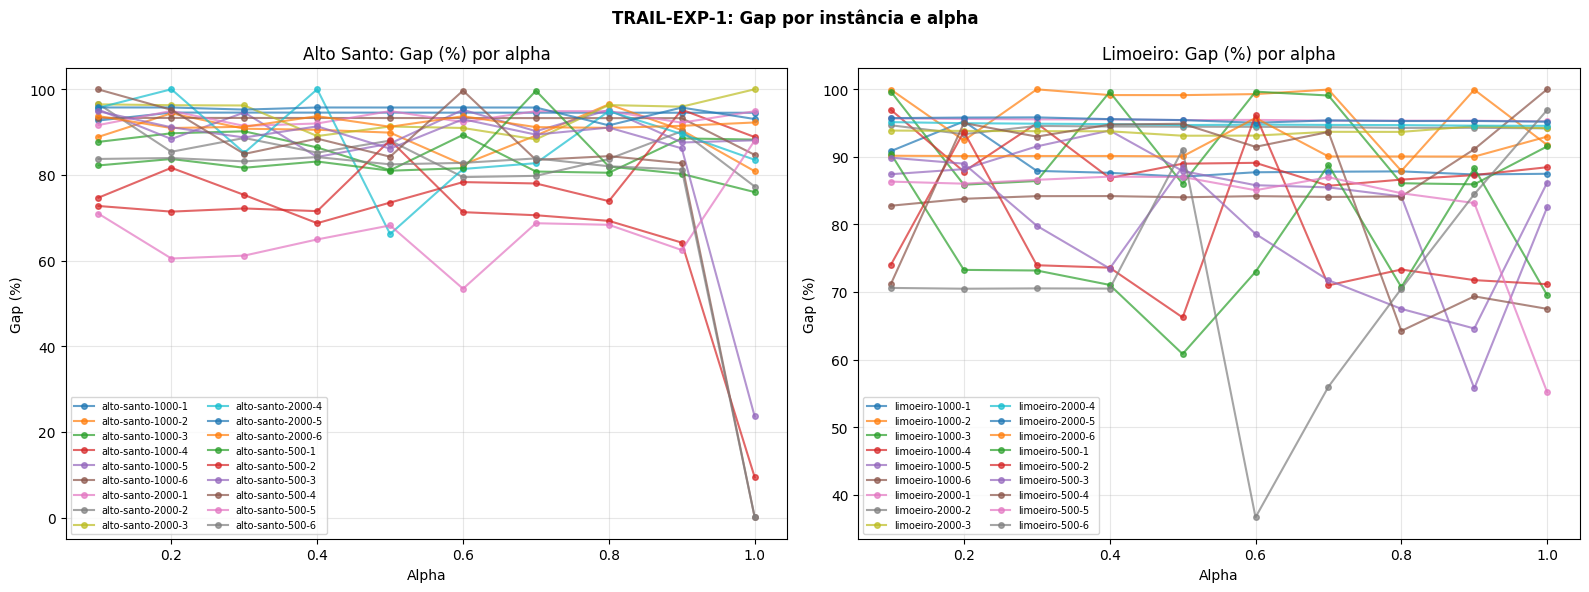

In [9]:
# Gap por alpha para cada instância (TRAIL-EXP-1)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for inst_name, grp in df_best.groupby("instance_name"):
    grp_sorted = grp.sort_values("alpha")
    city = inst_name.split("-")[0]
    ax = axes[0] if city == "alto" else axes[1]
    ax.plot(grp_sorted["alpha"], grp_sorted["gap_pct"], "o-", label=inst_name, markersize=4, alpha=0.7)

axes[0].set_title("Alto Santo: Gap (%) por alpha")
axes[1].set_title("Limoeiro: Gap (%) por alpha")
for ax in axes:
    ax.set_xlabel("Alpha")
    ax.set_ylabel("Gap (%)")
    ax.legend(fontsize=7, ncol=2)
plt.suptitle("TRAIL-EXP-1: Gap por instância e alpha", fontweight="bold")
plt.tight_layout()
plt.show()

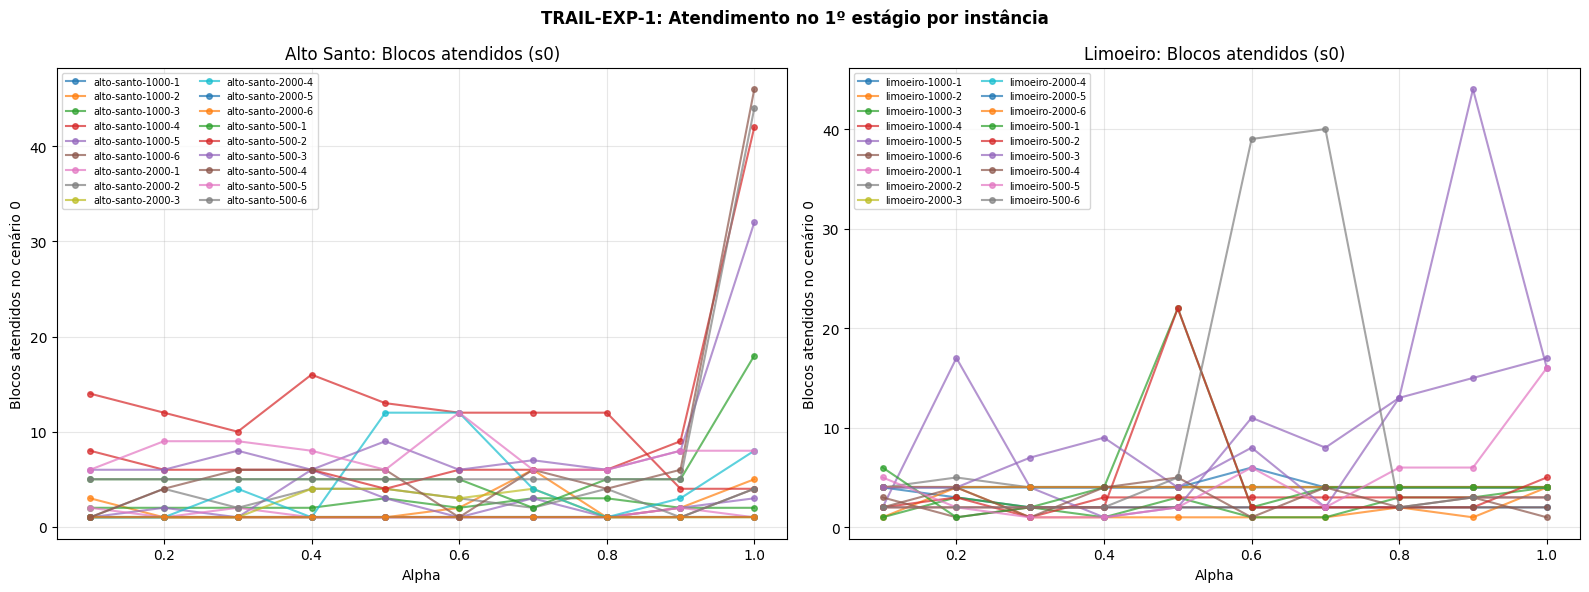

In [10]:
# Blocos atendidos no s0 por alpha, por instância
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for inst_name, grp in df_best.groupby("instance_name"):
    grp_sorted = grp.sort_values("alpha")
    city = inst_name.split("-")[0]
    ax = axes[0] if city == "alto" else axes[1]
    ax.plot(grp_sorted["alpha"], grp_sorted["attended_s0"], "o-", label=inst_name, markersize=4, alpha=0.7)

axes[0].set_title("Alto Santo: Blocos atendidos (s0)")
axes[1].set_title("Limoeiro: Blocos atendidos (s0)")
for ax in axes:
    ax.set_xlabel("Alpha")
    ax.set_ylabel("Blocos atendidos no cenário 0")
    ax.legend(fontsize=7, ncol=2)
plt.suptitle("TRAIL-EXP-1: Atendimento no 1º estágio por instância", fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Dados de input: blocos, casos e impacto do alpha

Cruzamos os resultados com as informações do grafo e cenários para entender:
- Quantos blocos tem cada instância e quantos casos totalizam?
- Quantos blocos o modelo atendeu no cenário 0 e que % dos casos isso representa?
- Como isso varia com alpha?

In [11]:
# Montar DataFrame de input
input_rows = []
for name, info in inst_data.items():
    g = info["graph"]
    sc = info.get("scenarios", {})
    avg_scenario_cases = 0
    if sc and sc.get("scenarios"):
        avg_scenario_cases = np.mean([s["total_cases"] for s in sc["scenarios"]])
    input_rows.append({
        "instance_name": name,
        "N_input": g["N"], "M_input": g["M"], "B_total": g["B"],
        "blocks_with_cases": g["blocks_with_cases"],
        "total_cases_det": g["total_cases"],
        "S": sc.get("S", 0),
        "avg_cases_per_scenario": avg_scenario_cases,
    })
df_input = pd.DataFrame(input_rows)
df_input = df_input.sort_values("instance_name", key=lambda c: c.map(instance_sort_key))
df_input

,instance_name,N_input,M_input,B_total,blocks_with_cases,total_cases_det,S,avg_cases_per_scenario
12,alto-santo-500-1,117,336,52,31,142,50,29.92
13,alto-santo-500-2,117,336,52,14,33,50,32.60
14,alto-santo-500-3,117,336,52,23,76,50,30.18
15,alto-santo-500-4,117,336,52,22,60,50,30.58
16,alto-santo-500-5,117,336,52,17,53,50,30.72
17,alto-santo-500-6,117,336,52,32,157,50,32.82
0,alto-santo-1000-1,179,524,84,42,173,50,50.88
1,alto-santo-1000-2,179,524,84,18,38,50,51.52
2,alto-santo-1000-3,179,524,84,31,99,50,50.48
3,alto-santo-1000-4,179,524,84,30,81,50,46.70


In [12]:
# Cruzar: para TRAIL-EXP-1, juntar info de input com resultado
df_merged = df_best.merge(df_input, on="instance_name", how="left")

# Calcular: % dos blocos atendidos no s0 em relação ao total
df_merged["att_s0_pct_blocks"] = 100 * df_merged["attended_s0"] / df_merged["B_total"]

# Para calcular % dos casos atendidos, precisamos saber os casos dos blocos atendidos no s0.
# Como não temos essa info direta nos resultados (só o Y: lista de blocos), vamos calcular
# a partir dos blocos atendidos (attended_per_scenario[0] nos dá os IDs dos blocos do s0).
# Mas no parse atual, attended_s0 é o COUNT. Vamos enriquecer com os dados do grafo.

# % de blocos atendidos no s0
att_summary = df_merged.groupby("alpha").agg(
    att_s0_medio=("attended_s0", "mean"),
    att_s0_pct_medio=("att_s0_pct_blocks", "mean"),
    B_medio=("B_total", "mean"),
    cases_det_medio=("total_cases_det", "mean"),
    LB_medio=("LB", "mean"),
    gap_medio=("gap_pct", "mean"),
).reset_index()
att_summary

,alpha,att_s0_medio,att_s0_pct_medio,B_medio,cases_det_medio,LB_medio,gap_medio
0,0.1,3.277778,3.640174,182.0,161.444444,15.173056,89.216815
1,0.2,3.722222,3.805394,182.0,161.444444,16.387889,88.761542
2,0.3,3.250000,3.740794,182.0,161.444444,17.754000,87.359294
3,0.4,3.638889,4.210240,182.0,161.444444,17.328667,87.301375
4,0.5,4.916667,5.753543,182.0,161.444444,18.226389,86.715329
5,0.6,4.972222,5.619090,182.0,161.444444,18.171556,86.764153
6,0.7,4.611111,5.276106,182.0,161.444444,17.994222,86.884028
7,0.8,3.833333,4.093453,182.0,161.444444,19.194152,85.386402
8,0.9,4.833333,4.828129,182.0,161.444444,17.371528,85.960132
9,1.0,9.055556,13.460057,182.0,161.444444,24.841667,78.272108


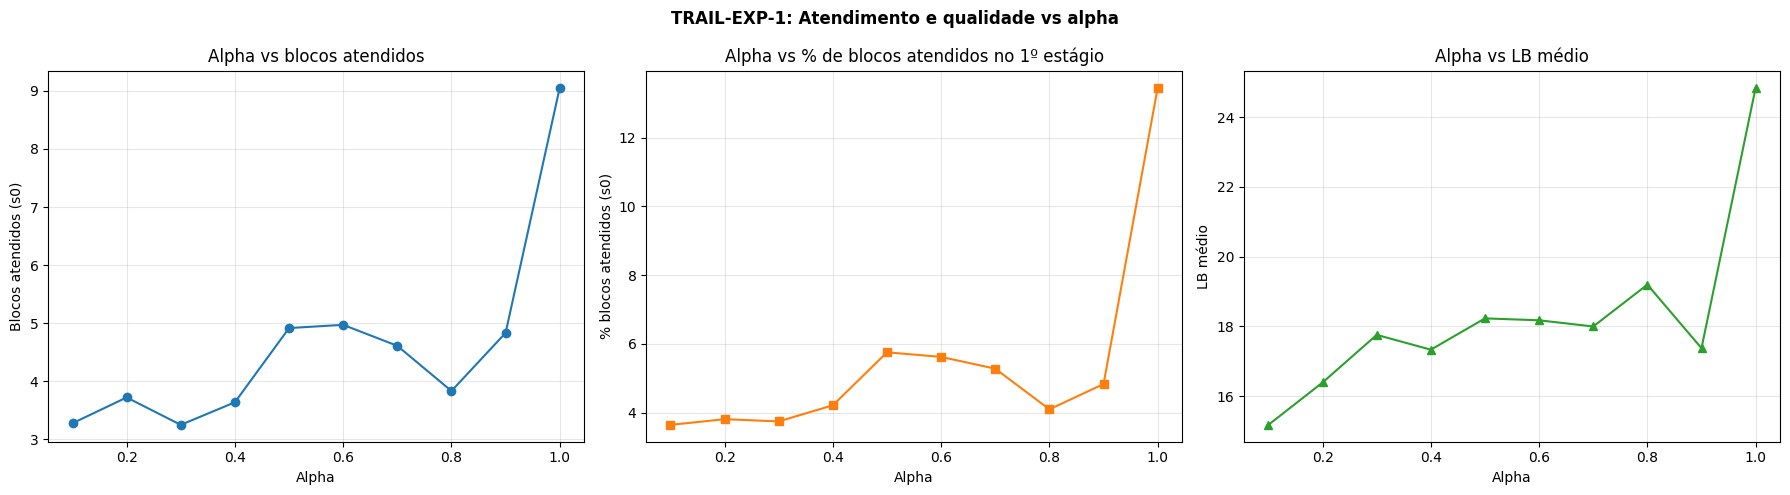

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(att_summary["alpha"], att_summary["att_s0_medio"], "o-", color="C0", label="Blocos atendidos")
ax.set_xlabel("Alpha")
ax.set_ylabel("Blocos atendidos (s0)")
ax.set_title("Alpha vs blocos atendidos")

ax = axes[1]
ax.plot(att_summary["alpha"], att_summary["att_s0_pct_medio"], "s-", color="C1")
ax.set_xlabel("Alpha")
ax.set_ylabel("% blocos atendidos (s0)")
ax.set_title("Alpha vs % de blocos atendidos no 1º estágio")

ax = axes[2]
ax.plot(att_summary["alpha"], att_summary["LB_medio"], "^-", color="C2")
ax.set_xlabel("Alpha")
ax.set_ylabel("LB médio")
ax.set_title("Alpha vs LB médio")

plt.suptitle("TRAIL-EXP-1: Atendimento e qualidade vs alpha", fontweight="bold")
plt.tight_layout()
plt.show()

In [14]:
# Tabela detalhada por instância para um alpha fixo (alpha=1.0 e alpha=0.1)
for a in [0.1, 0.5, 1.0]:
    sub = df_merged[df_merged["alpha"] == a][["instance_name", "B_total", "total_cases_det",
        "attended_s0", "att_s0_pct_blocks", "LB", "UB", "gap_pct", "Runtime"]].copy()
    sub = sub.sort_values("instance_name", key=lambda c: c.map(instance_sort_key))
    print(f"\n=== Alpha = {a} ===")
    print(sub.to_string(index=False))


=== Alpha = 0.1 ===
    instance_name  B_total  total_cases_det  attended_s0  att_s0_pct_blocks     LB       UB   gap_pct   Runtime
 alto-santo-500-1       52              142            5           9.615385 30.584 171.8800 82.206190  578.5030
 alto-santo-500-2       52               33            8          15.384615 17.858  65.5000 72.735878  388.0270
 alto-santo-500-3       52               76            6          11.538462  5.386 104.4200 94.841984  591.8430
 alto-santo-500-4       52               60            1           1.923077  0.048  90.5000 99.946961  546.1390
 alto-santo-500-5       52               53            6          11.538462 24.310  83.6400 70.934959  272.2430
 alto-santo-500-6       52              157            5           9.615385 30.888 189.7400 83.720881  729.5500
alto-santo-1000-1       84              173            1           1.190476 16.108 220.5800 92.697434  267.9980
alto-santo-1000-2       84               38            3           3.571429  9.642 

## 6. Análise do gap não-monotônico

O gap médio não decresce monotonicamente com alpha porque:
- **Instâncias heterogêneas**: diferentes tamanhos (N, B, casos) reagem de formas opostas ao alpha.
- **Trade-off**: alpha baixo prioriza o 2º estágio, alpha alto prioriza o 1º estágio. Instâncias com muitos cenários complexos se beneficiam de alphas intermediários.
- **Time limit**: com alpha alto o modelo tenta atender mais blocos no 1º estágio, o que pode consumir mais tempo no solver e gerar UBs piores (timeout).

Vamos quantificar isso separando por tamanho de instância.

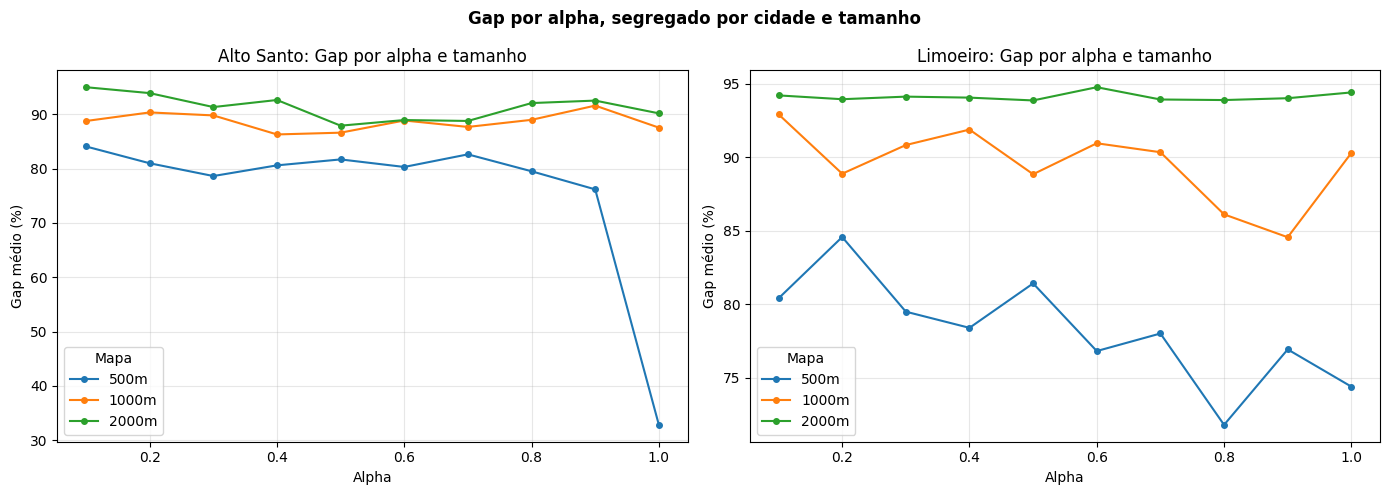

In [15]:
# Separar por tamanho do mapa
df_merged["map_size"] = df_merged["instance_name"].apply(
    lambda x: int(x.split("-")[-2]) if x.split("-")[-2].isdigit() else 0
)
df_merged["city"] = df_merged["instance_name"].apply(
    lambda x: "-".join(x.split("-")[:-2])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for (city, size), grp in df_merged.groupby(["city", "map_size"]):
    by_a = grp.groupby("alpha")["gap_pct"].mean()
    ax = axes[0] if city == "alto-santo" else axes[1]
    ax.plot(by_a.index, by_a.values, "o-", label=f"{size}m", markersize=4)

axes[0].set_title("Alto Santo: Gap por alpha e tamanho")
axes[1].set_title("Limoeiro: Gap por alpha e tamanho")
for ax in axes:
    ax.set_xlabel("Alpha")
    ax.set_ylabel("Gap médio (%)")
    ax.legend(title="Mapa")
plt.suptitle("Gap por alpha, segregado por cidade e tamanho", fontweight="bold")
plt.tight_layout()
plt.show()

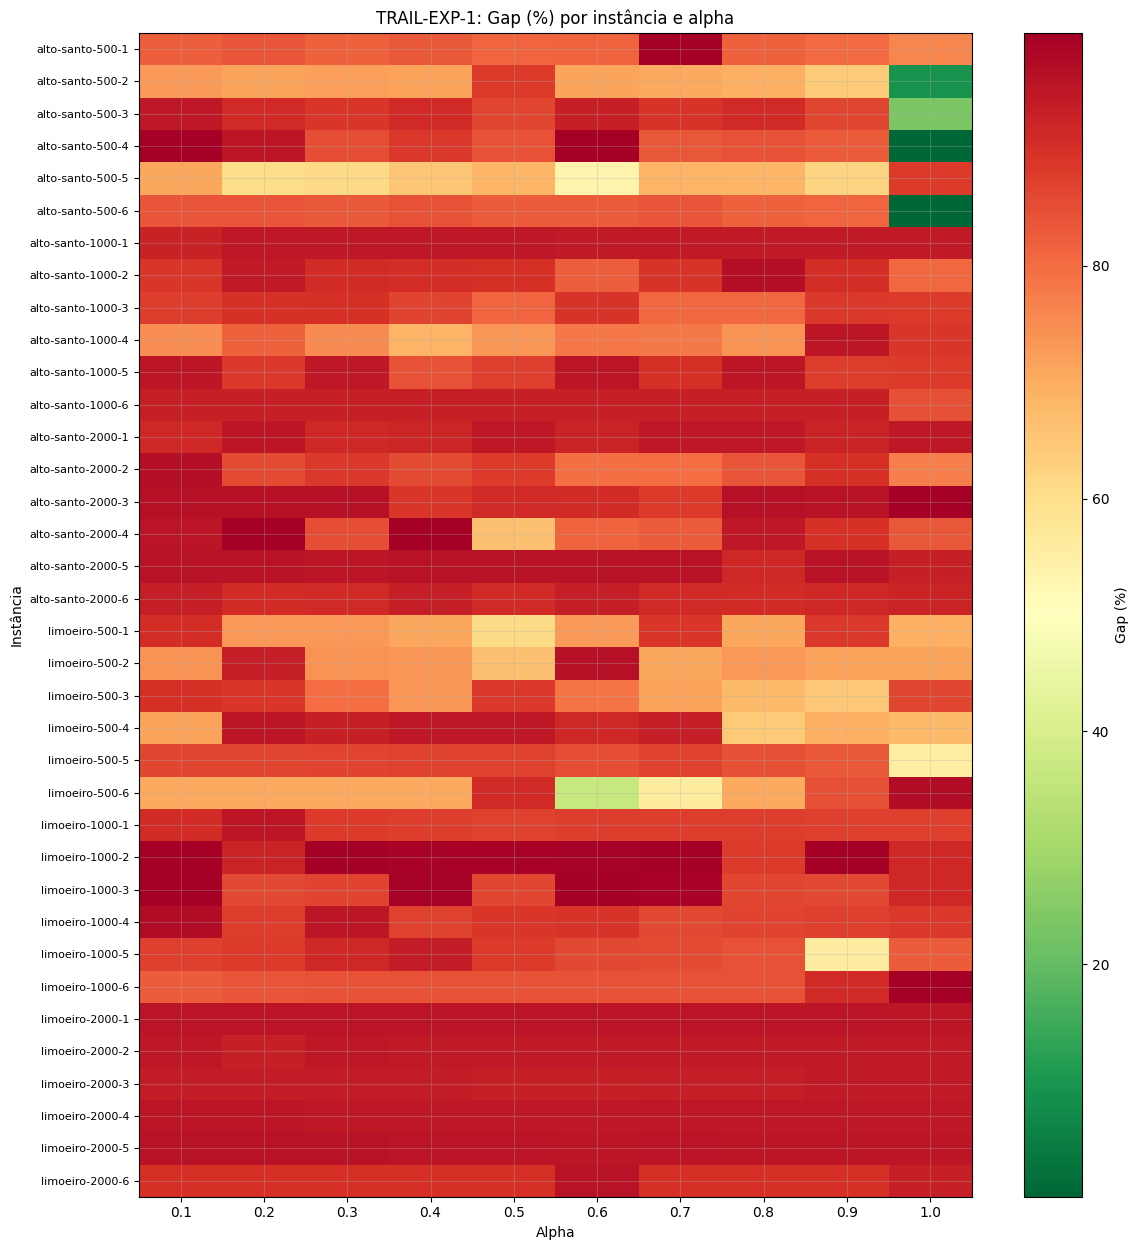

In [16]:
# Heatmap: gap por (instância × alpha) para ver a heterogeneidade
pivot_gap = df_best.pivot_table(index="instance_name", columns="alpha", values="gap_pct")
pivot_gap = pivot_gap.loc[sorted(pivot_gap.index, key=instance_sort_key)]

fig, ax = plt.subplots(figsize=(12, max(6, len(pivot_gap) * 0.35)))
im = ax.imshow(pivot_gap.values, aspect="auto", cmap="RdYlGn_r")
ax.set_xticks(range(len(pivot_gap.columns)))
ax.set_xticklabels([f"{a:.1f}" for a in pivot_gap.columns])
ax.set_yticks(range(len(pivot_gap.index)))
ax.set_yticklabels(pivot_gap.index, fontsize=8)
ax.set_xlabel("Alpha")
ax.set_ylabel("Instância")
ax.set_title("TRAIL-EXP-1: Gap (%) por instância e alpha")
plt.colorbar(im, label="Gap (%)")
plt.tight_layout()
plt.show()

In [17]:
# Correlação entre características do input e gap para alpha=1.0
sub = df_merged[df_merged["alpha"] == 1.0].copy()
print("Correlação com gap_pct (alpha=1.0):")
for col in ["N_input", "M_input", "B_total", "total_cases_det", "blocks_with_cases"]:
    corr = sub["gap_pct"].corr(sub[col])
    print(f"  {col}: r = {corr:.3f}")

Correlação com gap_pct (alpha=1.0):
  N_input: r = 0.402
  M_input: r = 0.399
  B_total: r = 0.394
  total_cases_det: r = 0.275
  blocks_with_cases: r = 0.331


## 7. Exportação LaTeX (cada configuração × alpha)

Cada combinação `experiment-{alpha}-{model}-{model_type}-{prep}` é exportada como tabela LaTeX.

In [18]:
def build_model_table_df(df_one_exp: pd.DataFrame) -> pd.DataFrame:
    df = df_one_exp.copy()
    df = df.rename(columns={
        "N": "|V|", "M": "|A|", "B": "|B|",
        "attended_s0": "Attended Blocks",
        "gap_pct": "gap (%)",
        "Gurobi_Nodes": "#B&B Nodes",
        "Lazy_cuts": "Lazy Cuts",
        "Runtime": "Exec. Time (s)",
        "instance_name": "Instance",
    })
    cols = ["Instance", "|V|", "|A|", "|B|", "S", "Alpha", "Attended Blocks", "LB", "UB", "gap (%)",
            "#B&B Nodes", "Lazy Cuts", "Exec. Time (s)"]
    return df[[c for c in cols if c in df.columns]]

def export_config_to_latex(exp_name: str, df_full: pd.DataFrame, out_dir: Path) -> str:
    df_exp = df_full[df_full["experiment"] == exp_name].copy()
    if df_exp.empty:
        return ""
    df_exp = df_exp.sort_values("instance_name", key=lambda c: c.map(instance_sort_key))
    table_df = build_model_table_df(df_exp)
    parts = exp_name.replace("experiment-", "").split("-")
    alpha, model, model_type, prep = parts[0], parts[1], parts[2], parts[3]
    caption = f"Results of the Stochastic Model {model}-CBRP-{model_type} (alpha={alpha}, preprocessing={prep})."
    label = f"tab:stoc-{model.lower()}-{model_type.lower()}-a{alpha}-p{prep}".replace(".", "")
    latex = export_model_config_to_latex(table_df, caption=caption, label=label, use_rowcolor=True)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    fname = f"table-{exp_name}.tex"
    (out_dir / fname).write_text(latex, encoding="utf-8")
    return str(out_dir / fname)

In [19]:
OUT_LATEX = Path("latex-tables-model")
exported = []
for exp_name in sorted(df_all["experiment"].unique()):
    path = export_config_to_latex(exp_name, df_all, OUT_LATEX)
    if path:
        exported.append(path)
print(f"Exportadas {len(exported)} tabelas em {OUT_LATEX}/")
if exported:
    print("Exemplo:")
    print(Path(exported[0]).read_text()[:800])

Exportadas 80 tabelas em latex-tables-model/
Exemplo:
\begin{table}[ht!]
\centering
\caption{Results of the Stochastic Model TRAIL-CBRP-EXP (alpha=0.1, preprocessing=0).}
\label{tab:stoc-trail-exp-a01-p0}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lrrrrrrrrrrrr}
\toprule
\multicolumn{1}{c}{\textbf{Instance}} & \multicolumn{1}{c}{\textbf{|V|}} & \multicolumn{1}{c}{\textbf{|A|}} & \multicolumn{1}{c}{\textbf{|B|}} & \multicolumn{1}{c}{\textbf{S}} & \multicolumn{1}{c}{\textbf{Alpha}} & \multicolumn{1}{c}{\textbf{\begin{tabular}[c]{@{}c@{}}Attended\\ Blocks\end{tabular}}} & \multicolumn{1}{c}{\textbf{LB}} & \multicolumn{1}{c}{\textbf{UB}} & \multicolumn{1}{c}{\textbf{gap (\%)}} & \multicolumn{1}{c}{\textbf{\begin{tabular}[c]{@{}c@{}}\#B\&B\\ Nodes\end{tabular}}} & \multicolumn{1}{c}{\textbf{\begin{tabular}[c]{@{}c@{}}Lazy\\ Cuts\end{tabular}}} & 
